# Perceptein has properties related to the Softmax Function

## Intro

The softmax function is a mathematical function commonly used in machine learning, particularly in multi-class classification tasks. It takes as input a vector of real numbers and normalizes them into a probability distribution. The output of the softmax function is a vector of probabilities, where each element represents the probability of the corresponding class.

The softmax function is defined as follows:

```
softmax(x_i) = exp(x_i) / sum(exp(x_j))
```

where `x_i` is the input value of the `i-th` element in the vector, `exp` denotes the exponential function, and the denominator is the sum of the exponential values of all elements in the vector.

In [2]:
# @title Settings
import pandas as pd
import io
import requests
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files

import seaborn as sns
import numpy as np
from scipy.optimize import least_squares

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Set pandas display options
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns

# IMPORTANT: this ensures that all the figures imported into illustrator have editable texts.
plt.rcParams['svg.fonttype'] = 'none'
palette = sns.set_palette('husl')
sns.set(style='whitegrid', rc={'axes.labelsize': 16, 'axes.grid':False})

# This enables high res graphics inline
%config InlineBackend.figure_formats = {'png', 'retina'}

# Set plot display options
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': "Arial",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 110
   }
mpl.rcParams.update(params)
sns.set_style("ticks", {'axes.grid' : False})

# Set plot output options
output_dir = "/content/drive/MyDrive/perceptein/"
output_suffix = ""
output_formats = [".svg", ".pdf"]

mpl.rc('savefig', dpi=300)

# Define convenience function for saving figures

savefig = True
savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0}

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    if savefig:
        for output_format in output_formats:
            fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

Mounted at /content/drive


In [3]:
# @title Import data
tvmvp = "https://drive.google.com/uc?id=10kbY1-yI9cMV8eJ-PWKupnVzafRAaQ6K&export=download"
tevp = "https://drive.google.com/uc?id=1yAb7v9jB9c-nWQQj52KcO_QrKDzQzSYF&export=download"

response_tvmvp = requests.get(tvmvp).content
response_tevp = requests.get(tevp).content

RFP = pd.read_csv(io.StringIO(response_tvmvp.decode('utf-8')), header=None).T
GFP = pd.read_csv(io.StringIO(response_tevp.decode('utf-8')), header=None).T

RFP.columns = ['RFP']
GFP.columns = ['GFP']

#print(RFP)
#print(GFP)

data = pd.DataFrame()
data = pd.concat([RFP, GFP], axis=1)
RFP_data = data['RFP']
GFP_data = data['GFP']
#print(data)
#print("RFP_data:",RFP_data)
#print("GFP_data:",GFP_data)

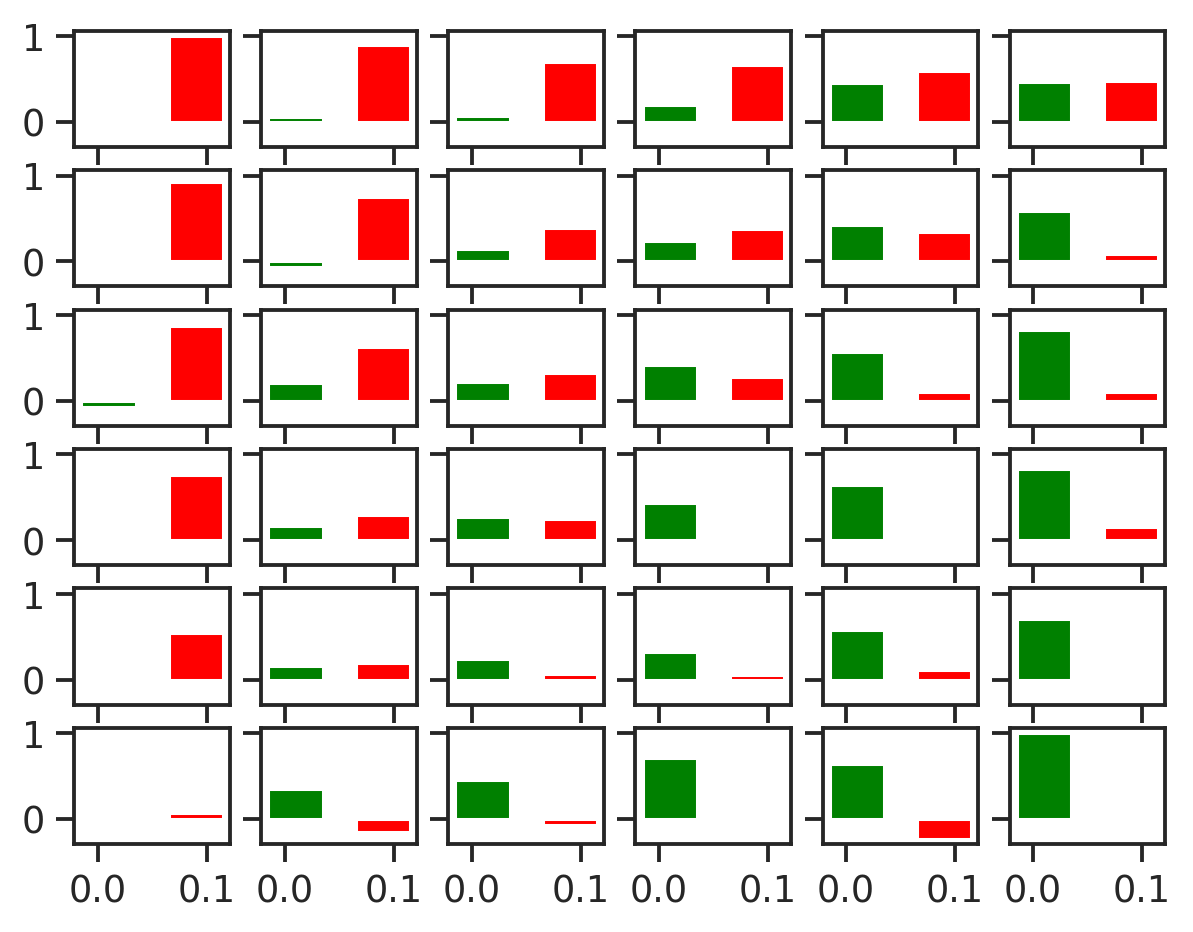

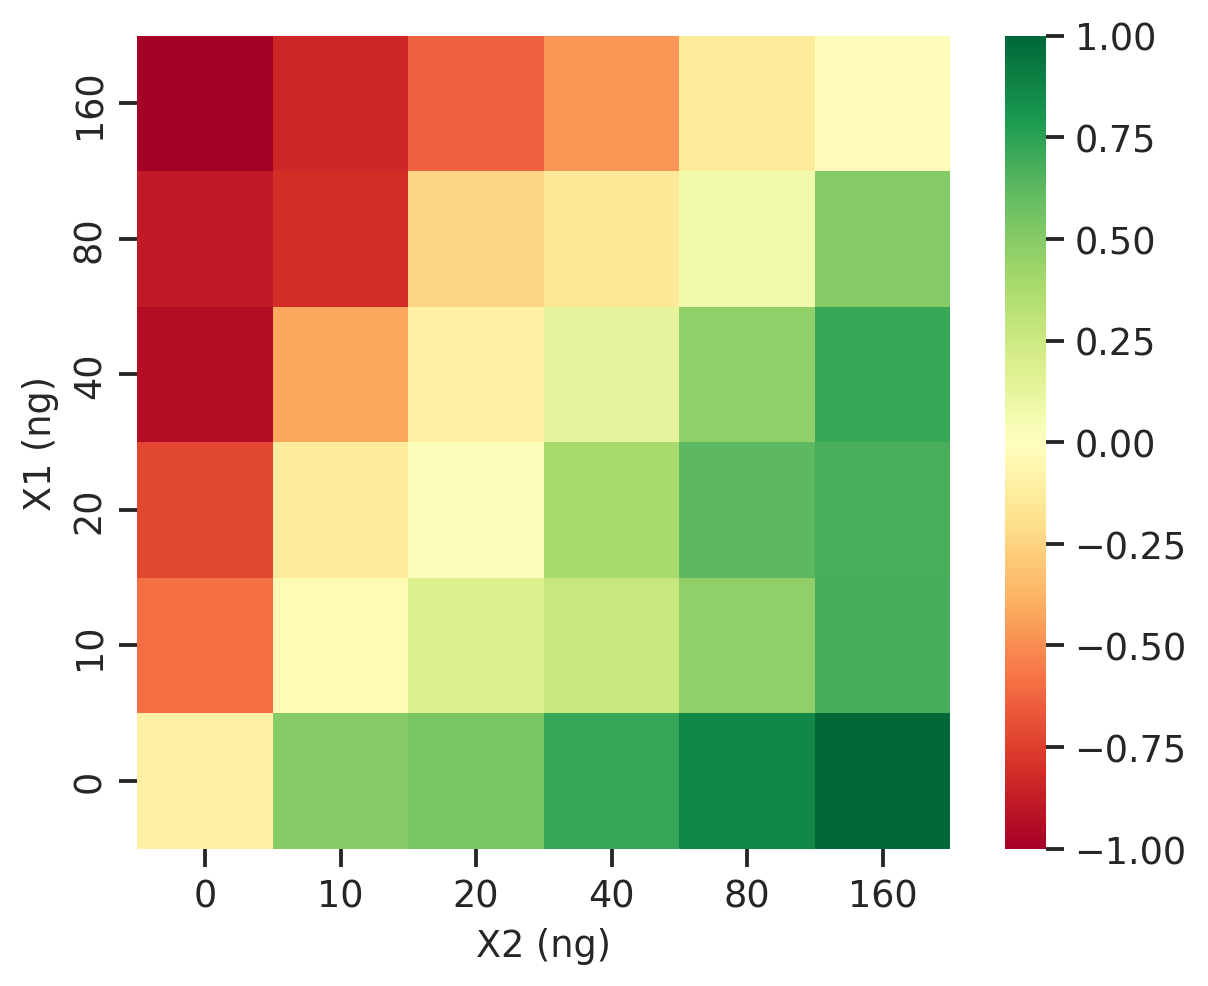

In [4]:
# @title Experimental data matrix
# the exp data
RFP_high = RFP_data[5]#3 can still use data from the 6 by 6 matrix
RFP_low = RFP_data[30]#12
normalized_RFP = (RFP_high - RFP_data[0:36])/(RFP_high - RFP_low)

GFP_high = GFP_data[30] #30
GFP_low = GFP_data[5] #5
normalized_GFP = (GFP_high - GFP_data[0:36])/(GFP_high - GFP_low)

# Plot the exp data
dimension = 6
fig, axs = plt.subplots(dimension, dimension, sharex=True, sharey=True) #dimension-by-dimension plot
diff_exp_matrix = np.zeros((dimension, dimension))
gfp_exp_matrix = np.zeros((dimension, dimension))
rfp_exp_matrix = np.zeros((dimension, dimension))

for i in range(dimension):
    for j in range(dimension):
        axs[dimension-1-i, j].bar(0.01, normalized_GFP.to_numpy()[dimension*i + j], 0.05, color='green')
        axs[dimension-1-i, j].bar(0.09, normalized_RFP.to_numpy()[dimension*i + j], 0.05, color='red')
        diff_exp_matrix[dimension-1-i][j] = normalized_GFP.to_numpy()[dimension*i + j] - normalized_RFP.to_numpy()[dimension*i + j]
        gfp_exp_matrix[dimension-1-i][j] = normalized_GFP.to_numpy()[dimension*i + j]
        rfp_exp_matrix[dimension-1-i][j] = normalized_RFP.to_numpy()[dimension*i + j]

# Plot the diff_exp_matrix
fig, ax = plt.subplots()
sns.heatmap(diff_exp_matrix, cmap = "RdYlGn", square=True, center = 0.0) #cmap = "RdYlGn"
x2 = np.array([0, 10, 20, 40, 80, 160])
x1 = np.array([160, 80, 40, 20, 10, 0])
ax.set_xticklabels(x2)
ax.set_yticklabels(x1)
plt.xlabel("X2 (ng)")
plt.ylabel("X1 (ng)")
plt.show()

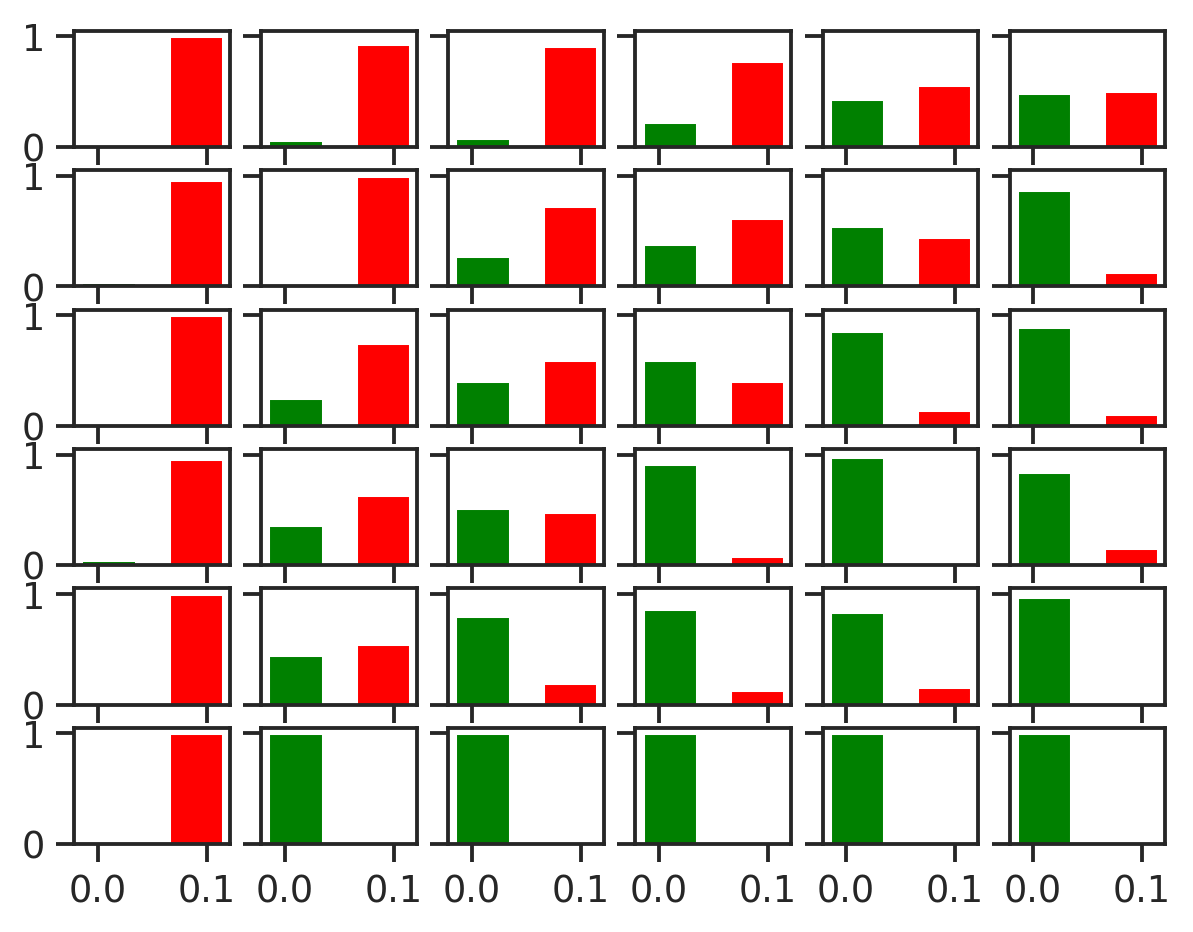

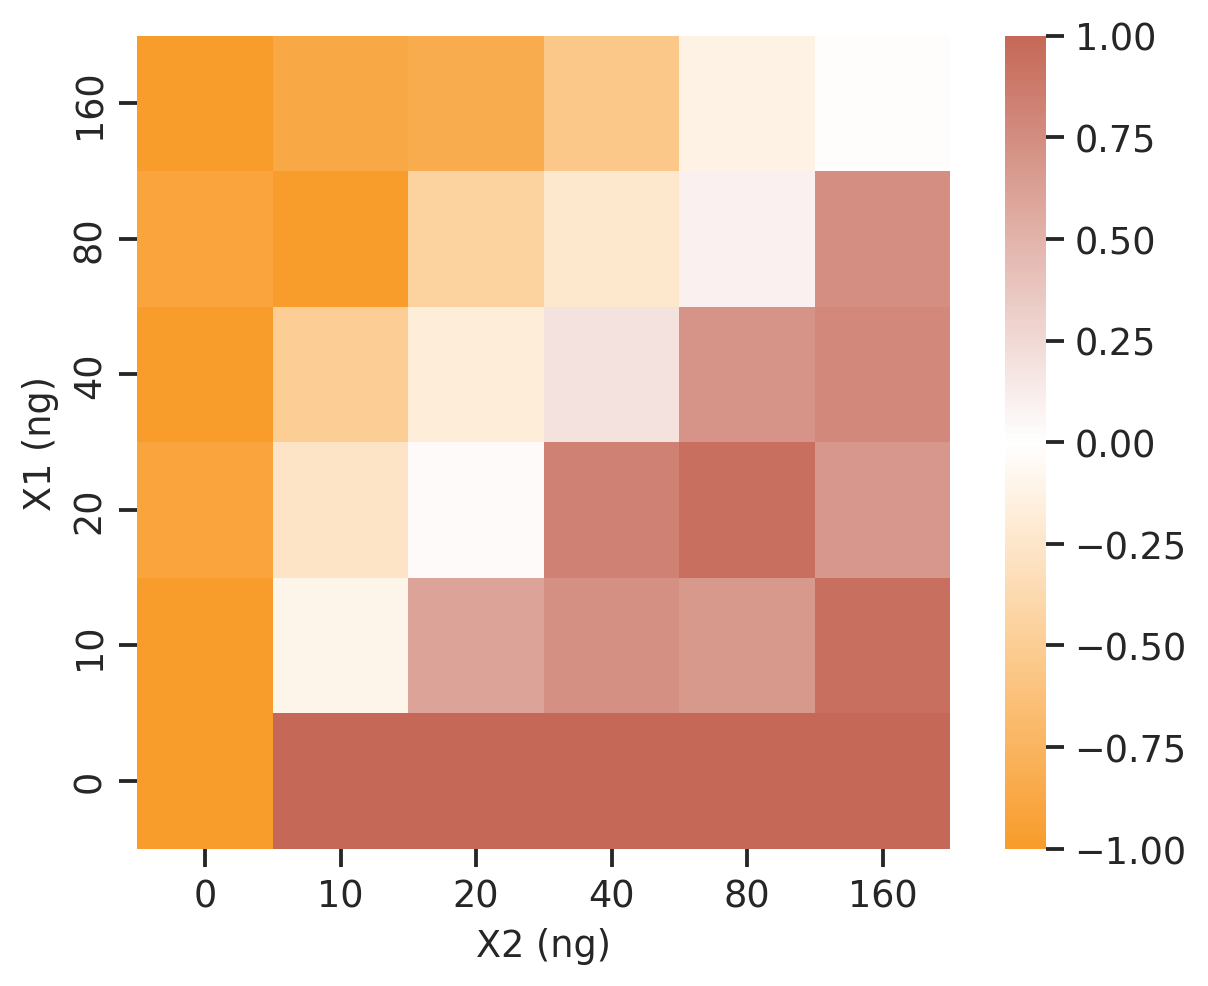

In [5]:
# @title Renormalized data matrix
# rge renormalized data
rfp_renor = np.where(normalized_RFP < 0, 0, normalized_RFP)
gfp_renor = np.where(normalized_GFP < 0, 0, normalized_GFP)
rfp_renor_data = rfp_renor/np.add(rfp_renor, gfp_renor)
gfp_renor_data = gfp_renor/np.add(rfp_renor, gfp_renor)
#print(data)
#print("rfp_renor_data:",rfp_renor_data)
#print("gfp_renor_data:",gfp_renor_data)

## Plot the renor data
dimension = 6
fig, axs = plt.subplots(dimension, dimension, sharex=True, sharey=True) #dimension-by-dimension plot
diff_renor_matrix = np.zeros((dimension, dimension))
gfp_renor_matrix = np.zeros((dimension, dimension))
rfp_renor_matrix = np.zeros((dimension, dimension))

for i in range(dimension):
    for j in range(dimension):
        axs[dimension-1-i, j].bar(0.01, gfp_renor_data[dimension*i + j], 0.05, color='green')
        axs[dimension-1-i, j].bar(0.09, rfp_renor_data[dimension*i + j], 0.05, color='red')
        diff_renor_matrix[dimension-1-i][j] = gfp_renor_data[dimension*i + j] - rfp_renor_data[dimension*i + j]
        gfp_renor_matrix[dimension-1-i][j] = gfp_renor_data[dimension*i + j]
        rfp_renor_matrix[dimension-1-i][j] = rfp_renor_data[dimension*i + j]

# the color map
my_gradient = LinearSegmentedColormap.from_list('my_gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#F89C2B-FFFFFF-C56857
    (0.000, (0.973, 0.612, 0.169)),
    (0.500, (1.000, 1.000, 1.000)),
    (1.000, (0.773, 0.408, 0.341))))

# Plot the diff_renor_matrix
fig, ax = plt.subplots()
sns.heatmap(diff_renor_matrix, cmap = my_gradient, square=True, center = 0.0) #cmap = "RdYlGn"
x2 = np.array([0, 10, 20, 40, 80, 160])
x1 = np.array([160, 80, 40, 20, 10, 0])
ax.set_xticklabels(x2)
ax.set_yticklabels(x1)
plt.xlabel("X2 (ng)")
plt.ylabel("X1 (ng)")
plt.savefig(output_dir + "renormalized.svg")
plt.show()

Beta: -0.10840962076053634


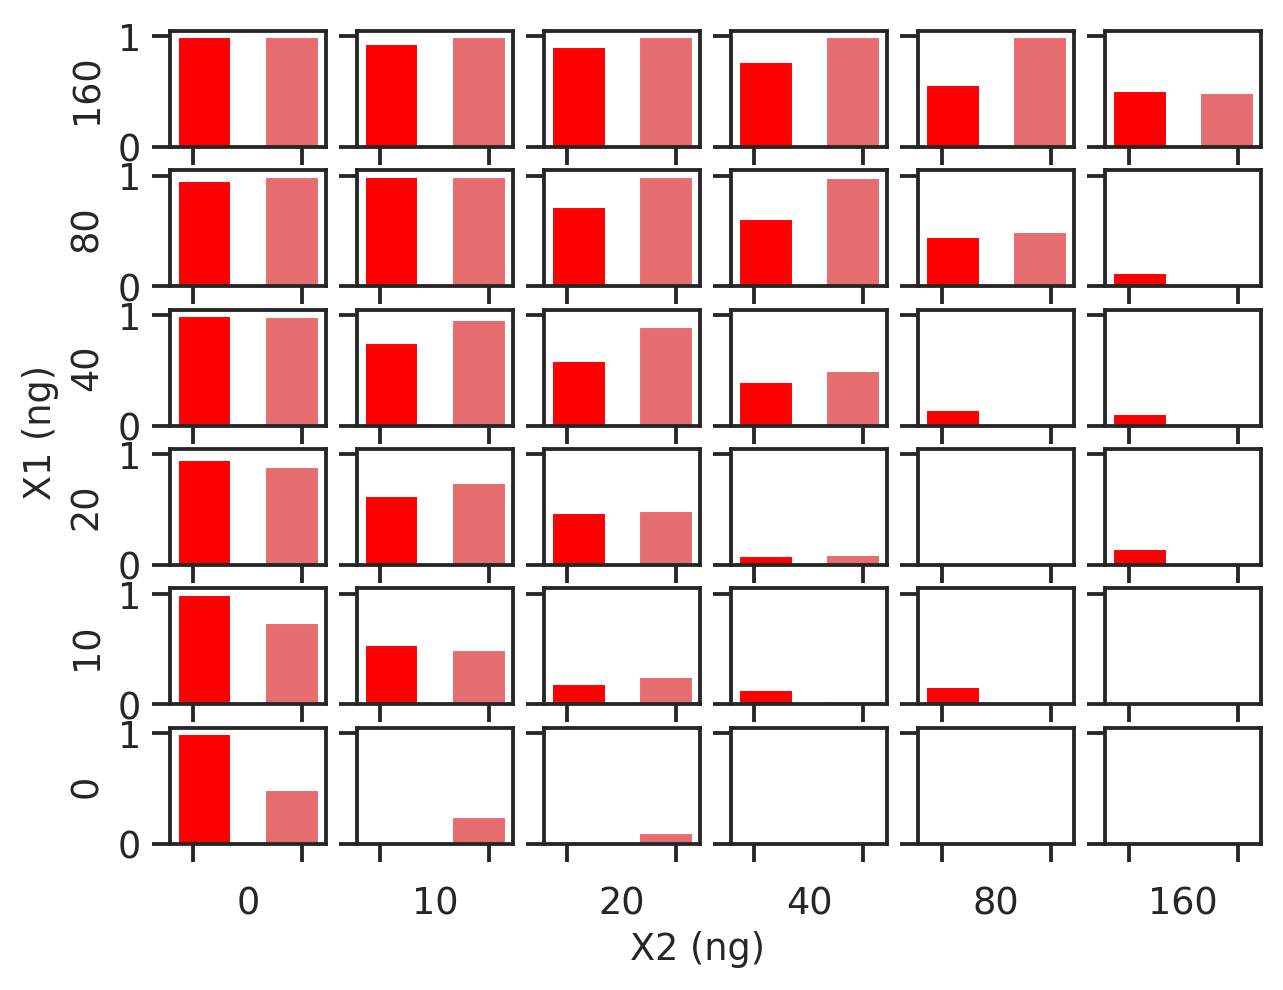

In [9]:
# @title Softmax Fitting-RFP
# Softmax function
def softmax_2d(beta, x1, x2):
    delta_x1 = np.exp(beta * x1) / (np.exp(beta * x1) + np.exp(beta * x2))
    return delta_x1

# Objective function
def objective_2d(beta, x1, x2, X):
    delta = softmax_2d(beta, x1, x2)
    residuals = np.abs(delta - X)
    return residuals

# x,y,delta_x1,pre_delta_x2
x1 = np.array([0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160])
x2 = np.array([0, 0, 0, 0, 0, 0, 10, 10, 10, 10, 10, 10, 20, 20, 20, 20, 20, 20, 40, 40, 40, 40, 40, 40, 80, 80, 80, 80, 80, 80, 160, 160, 160, 160, 160, 160])
rfp_fix_data = rfp_renor_data.reshape(-1)

# Fitting
result = least_squares(objective_2d, 1, args=(x1,x2,rfp_fix_data))
beta = result.x[0]
fixed_rfp_data = softmax_2d(beta, x1, x2)

# Plot the fitted data
dimension = 6
fig, axs = plt.subplots(dimension, dimension, sharex=True, sharey=True) #dimension-by-dimension plot
res_rfp_matrix = np.zeros((dimension, dimension))
rfp_fix_matrix = np.zeros((dimension, dimension))
fixed_rfp_matrix = np.zeros((dimension, dimension))

for i in range(dimension):
    for j in range(dimension):
        axs[dimension-1-i, j].set_xticklabels([])
        axs[dimension-1-i, j].bar(0.01, rfp_fix_data[dimension*i + j], 0.05, color='red')
        axs[dimension-1-i, j].bar(0.09, fixed_rfp_data[dimension*i + j], 0.05, color='#e56d6f')
        #res_rfp_matrix[dimension-1-i][j] = np.abs(fixed_rfp_data[dimension*i + j] - rfp_fix_data[dimension*i + j])
        rfp_fix_matrix[dimension-1-i][j] = rfp_fix_data[dimension*i + j]
        fixed_rfp_matrix[dimension-1-i][j] = fixed_rfp_data[dimension*i + j]

# label
X1 = [160, 80, 40, 20, 10, 0]
for i, ax in zip(X1, axs[:, 0]):
    ax.set_ylabel(i, fontsize=12)

X2 = [0, 10, 20, 40, 80, 160]
for j, ax in zip(X2, axs[-1, :]):
    ax.set_xlabel(j, fontsize=12)

fig.text(0.5, 0.00, 'X2 (ng)', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'X1 (ng)', va='center', rotation='vertical', fontsize=12)

print("Beta:",beta)

Beta: 0.10845619689340331


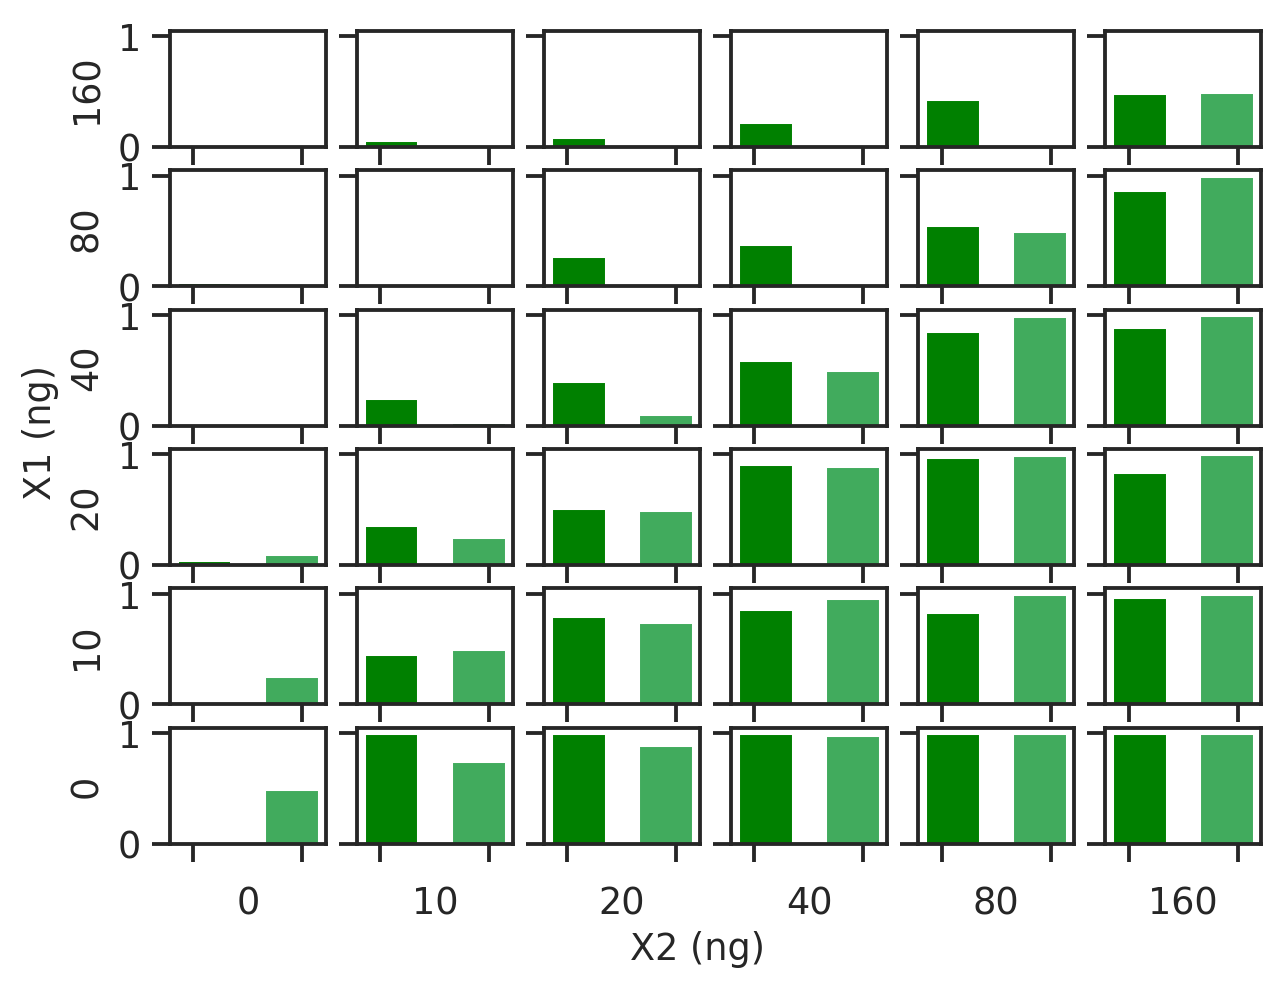

In [10]:
# @title Softmax Fitting-GFP
# Softmax function
def softmax_2d(beta, x1, x2):
    delta_x1 = np.exp(beta * x1) / (np.exp(beta * x1) + np.exp(beta * x2))
    return delta_x1

# Objective function
def objective_2d(beta, x1, x2, X):
    delta = softmax_2d(beta, x1, x2)
    residuals = np.abs(delta - X)
    return residuals

# x,y,delta_x1,pre_delta_x2
x1 = np.array([0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160, 0, 10, 20, 40, 80, 160])
x2 = np.array([0, 0, 0, 0, 0, 0, 10, 10, 10, 10, 10, 10, 20, 20, 20, 20, 20, 20, 40, 40, 40, 40, 40, 40, 80, 80, 80, 80, 80, 80, 160, 160, 160, 160, 160, 160])
gfp_fix_data = gfp_renor_data.reshape(-1)

# Fitting
result = least_squares(objective_2d, 1, args=(x1,x2,gfp_fix_data))
beta = result.x[0]
fixed_gfp_data = softmax_2d(beta, x1, x2)

# Plot the fitted data
dimension = 6
fig, axs = plt.subplots(dimension, dimension, sharex=True, sharey=True) #dimension-by-dimension plot
res_gfp_matrix = np.zeros((dimension, dimension))
gfp_fix_matrix = np.zeros((dimension, dimension))
fixed_gfp_matrix = np.zeros((dimension, dimension))

for i in range(dimension):
    for j in range(dimension):
        axs[dimension-1-i, j].set_xticklabels([])
        axs[dimension-1-i, j].bar(0.01, gfp_fix_data[dimension*i + j], 0.05, color='green')
        axs[dimension-1-i, j].bar(0.09, fixed_gfp_data[dimension*i + j], 0.05, color='#41ab5d')
        #res_gfp_matrix[dimension-1-i][j] = np.abs(fixed_gfp_data[dimension*i + j] - gfp_fix_data[dimension*i + j])
        gfp_fix_matrix[dimension-1-i][j] = gfp_fix_data[dimension*i + j]
        fixed_gfp_matrix[dimension-1-i][j] = fixed_gfp_data[dimension*i + j]

# label
X1 = [160, 80, 40, 20, 10, 0]
for i, ax in zip(X1, axs[:, 0]):
    ax.set_ylabel(i, fontsize=12)

X2 = [0, 10, 20, 40, 80, 160]
for j, ax in zip(X2, axs[-1, :]):
    ax.set_xlabel(j, fontsize=12)

fig.text(0.5, 0.00, 'X2 (ng)', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'X1 (ng)', va='center', rotation='vertical', fontsize=12)

print("Beta:",beta)

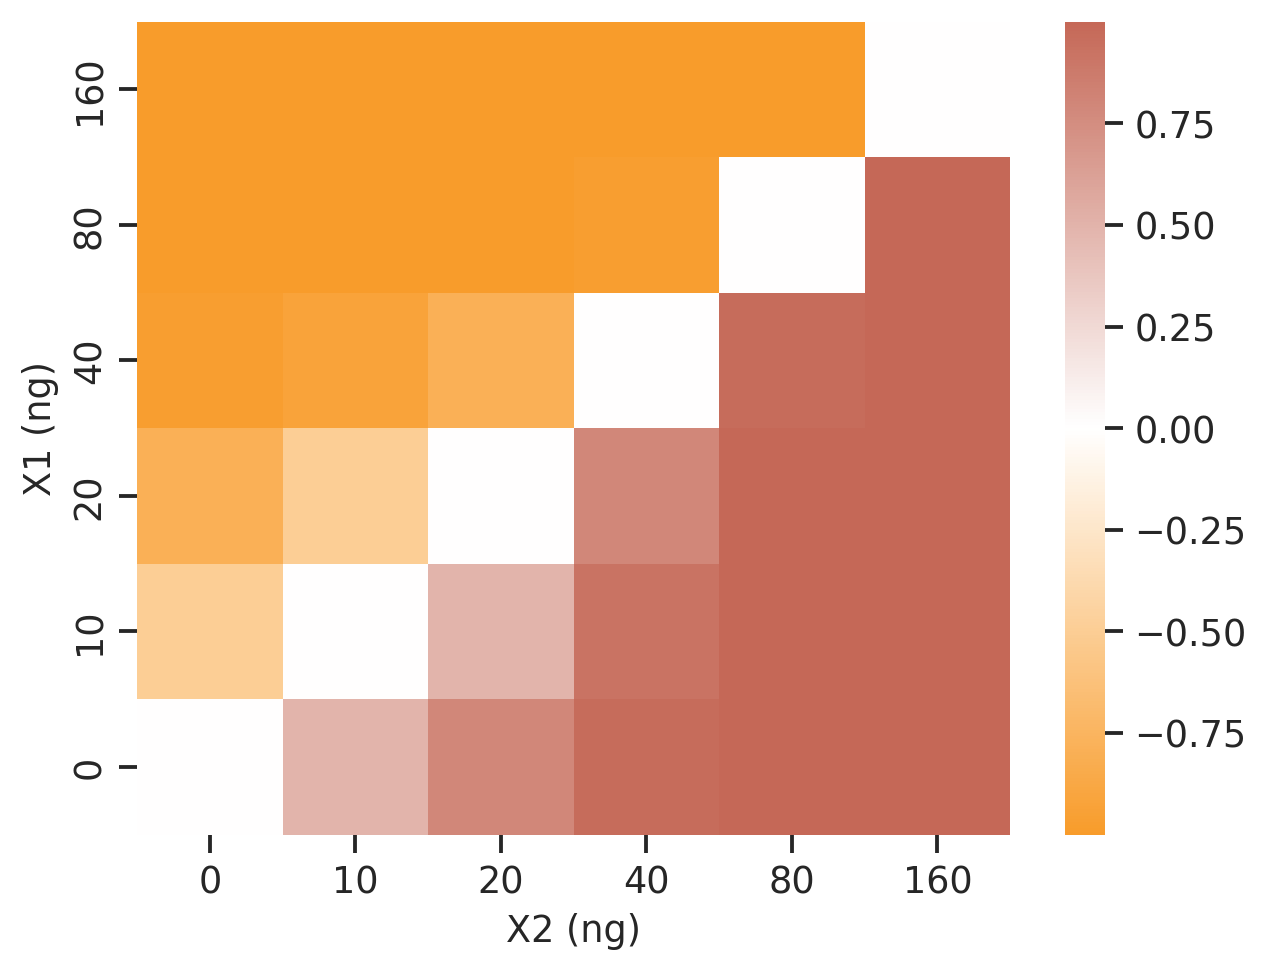

In [11]:
# @title Simulated data matrix
# the simulated data
simulated_data = fixed_gfp_matrix - fixed_rfp_matrix
# Plot the fixed_matrix heatmap
fig, ax = plt.subplots()
sns.heatmap(simulated_data, cmap = my_gradient) #cmap = "RdYlGn"
x2 = np.array([0, 10, 20, 40, 80, 160])
x1 = np.array([160, 80, 40, 20, 10, 0])
ax.set_xticklabels(x2)
ax.set_yticklabels(x1)
plt.xlabel("X2 (ng)")
plt.ylabel("X1 (ng)")
plt.savefig(output_dir + "simulated.svg")
plt.show()

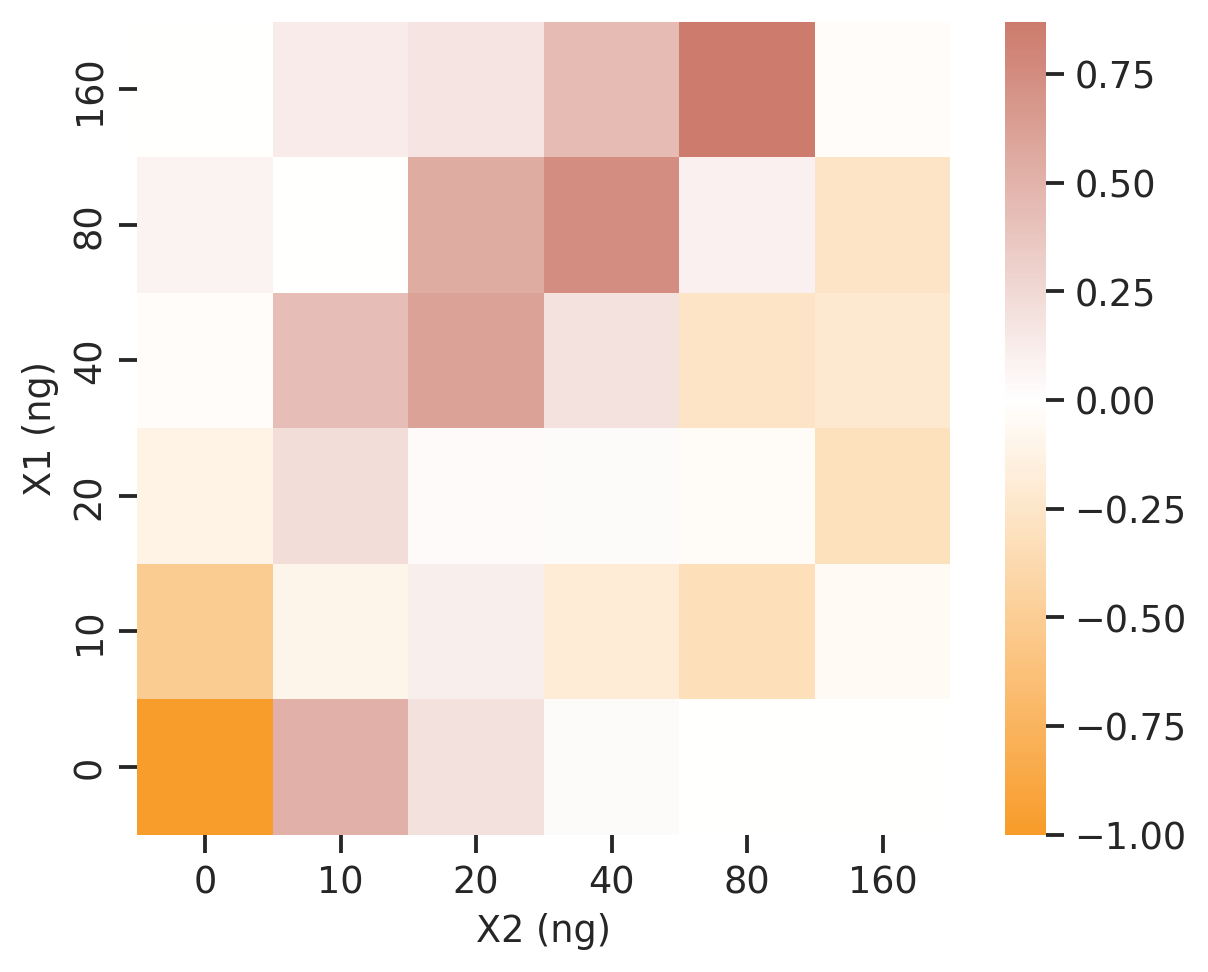

In [12]:
# @title Fitted difference matrix
# the diff data
diff_data = diff_renor_matrix - simulated_data

# Plot the res_matrix heatmap
fig, ax = plt.subplots()
sns.heatmap(diff_data, cmap = my_gradient, square=True, center = 0.0) #cmap = "RdYlGn
x2 = np.array([0, 10, 20, 40, 80, 160])
x1 = np.array([160, 80, 40, 20, 10, 0])
ax.set_xticklabels(x2)
ax.set_yticklabels(x1)
plt.xlabel("X2 (ng)")
plt.ylabel("X1 (ng)")
plt.savefig(output_dir + "diff.svg")
plt.show()